# Amazon Best Selling Books — Exploratory Data Analysis

This notebook loads the cleaned dataset and walks through author, book, genre,
year, and correlation analysis. All chart-generating logic lives in
`src/eda_analysis.py` — this notebook focuses on running that logic and
interpreting the results, not redefining plotting code.

In [1]:
import sys
sys.path.insert(0, '..')

from src.data_cleaning import load_raw_data, clean_dataset
from src import eda_analysis as eda

df = clean_dataset(load_raw_data('../data/raw/bestsellers_with_categories.csv'))
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## 1. Author Analysis

**Business question:** Which authors dominate the bestseller list, and does
appearing often correlate with quality (rating) or just volume (reviews)?

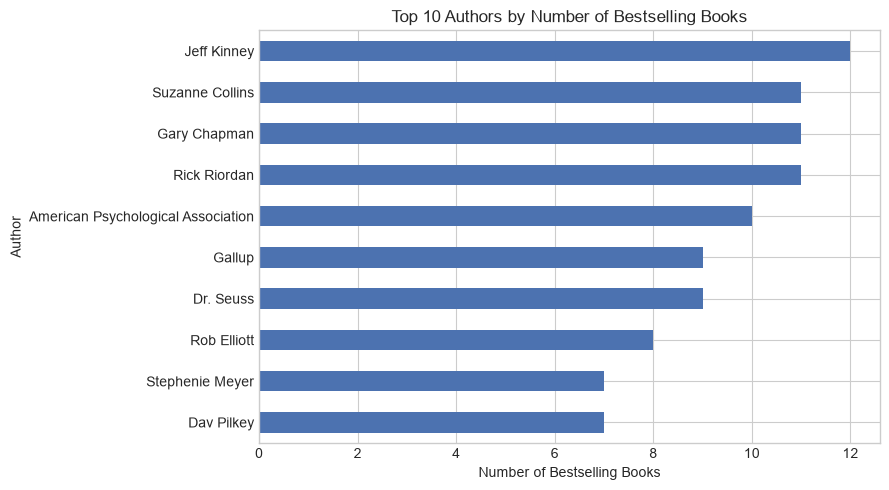

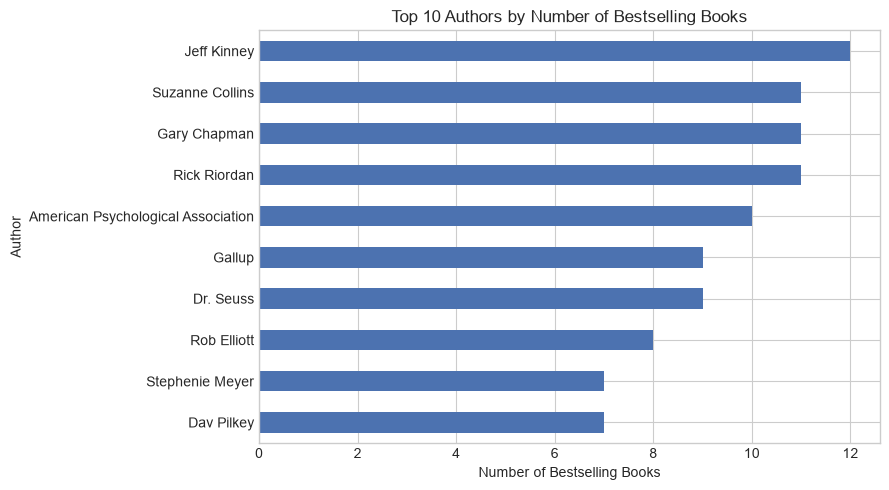

In [2]:
fig = eda.top_authors_by_book_count(df)
fig

**Insight:** Jeff Kinney (Diary of a Wimpy Kid), Suzanne Collins (Hunger Games),
and Rick Riordan lead by book count — all multi-book series authors. This tells
us bestseller *frequency* is often driven by franchise/series momentum rather
than a single standout title.

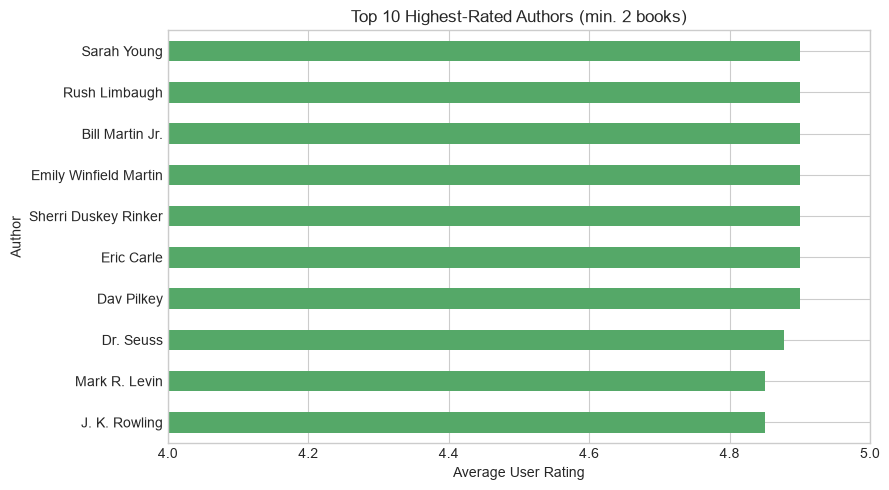

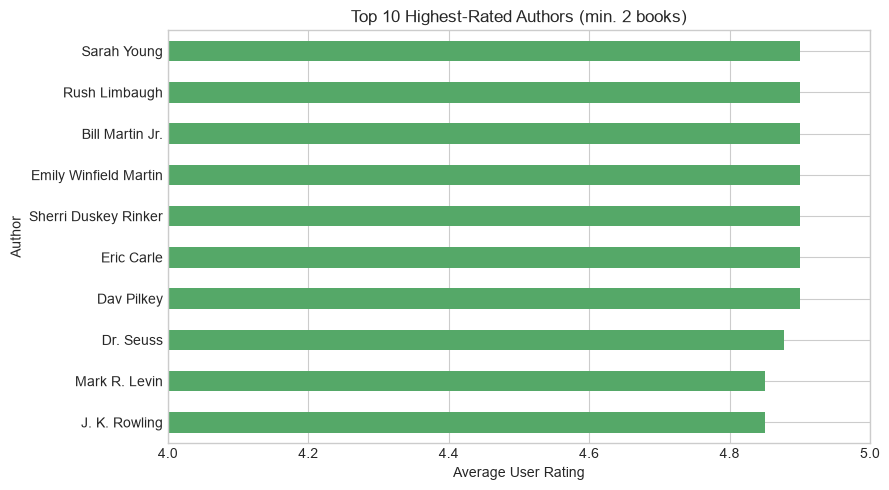

In [3]:
fig = eda.highest_rated_authors(df, min_books=2)
fig

Note: we filter to authors with at least 2 books here. Without that filter,
a one-hit author with a single 4.9 book would rank above a consistent author
averaging 4.7 across five books — which isn't a meaningful comparison.

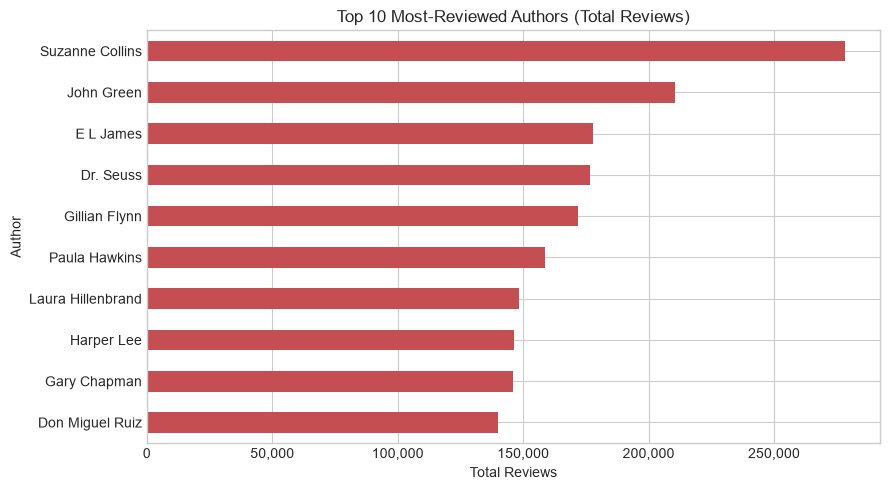

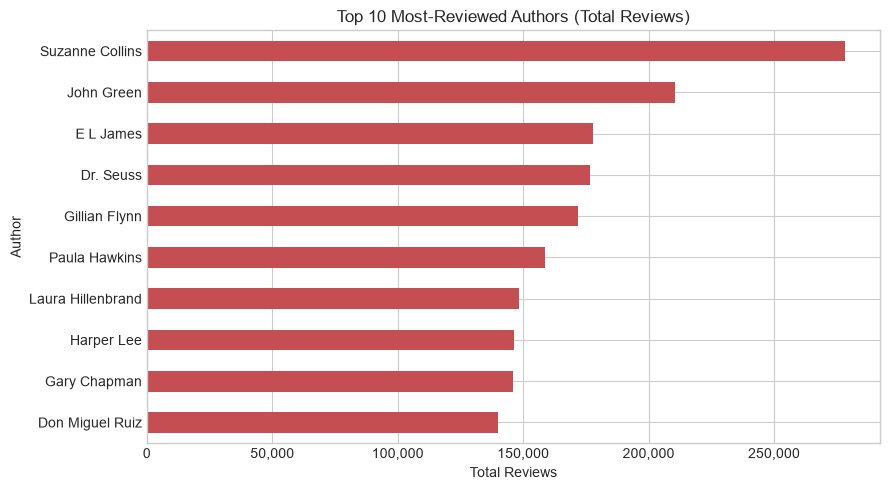

In [4]:
fig = eda.most_reviewed_authors(df)
fig

## 2. Book Analysis

**Business question:** What does the overall quality (rating) distribution
look like, and what are the price extremes?

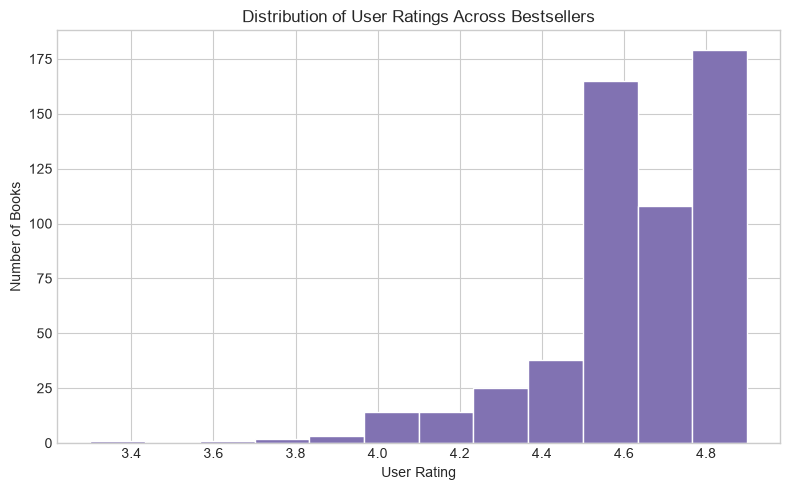

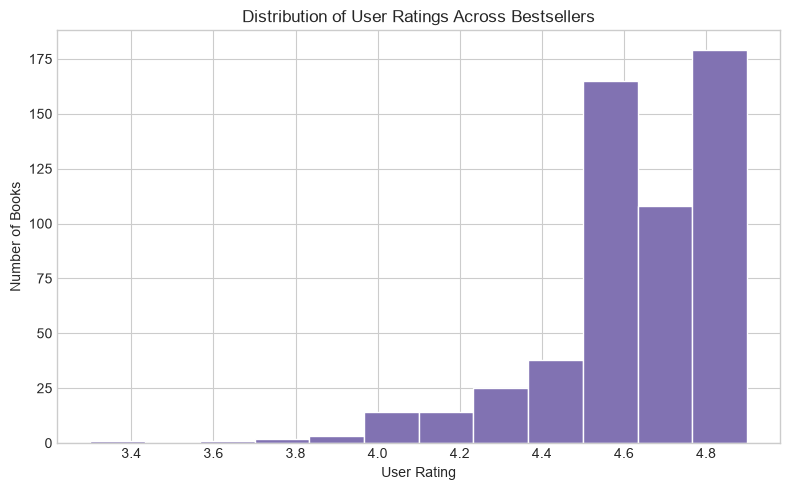

In [5]:
fig = eda.rating_distribution(df)
fig

**Insight:** Ratings cluster heavily between 4.5 and 4.9 — expected, since
this is a *bestseller* list, which is inherently rating-biased (poorly-rated
books rarely become bestsellers in the first place).

In [6]:
most_expensive, least_expensive = eda.price_extremes(df)
print("Most expensive books:")
display(most_expensive)
print("\nLeast expensive (free) books:")
display(least_expensive)

Most expensive books:


,name,author,price,year
69,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,105,2013
70,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,105,2014
473,The Twilight Saga Collection,Stephenie Meyer,82,2009
151,Hamilton: The Revolution,Lin-Manuel Miranda,54,2016
346,The Book of Basketball: The NBA According to T...,Bill Simmons,53,2009



Least expensive (free) books:


,name,author,price,year
42,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,0,2011
71,"Diary of a Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,0,2013
116,Frozen (Little Golden Book),RH Disney,0,2014
193,JOURNEY TO THE ICE P,RH Disney,0,2014
219,Little Blue Truck,Alice Schertle,0,2014


**Insight:** The $0 books are not data errors — they're genuine promotional
or public-domain listings (e.g. *To Kill a Mockingbird* during a known Kindle
giveaway period). This was verified in the cleaning phase before deciding not
to impute a fake price.

## 3. Genre Analysis

**Business question:** Does Fiction differ meaningfully from Non Fiction in
rating, price, or engagement (reviews)?

,avg_rating,avg_price,avg_reviews,count
genre,,,,
Fiction,4.648333,10.850000,15683.791667,240
Non Fiction,4.595161,14.841935,9065.145161,310


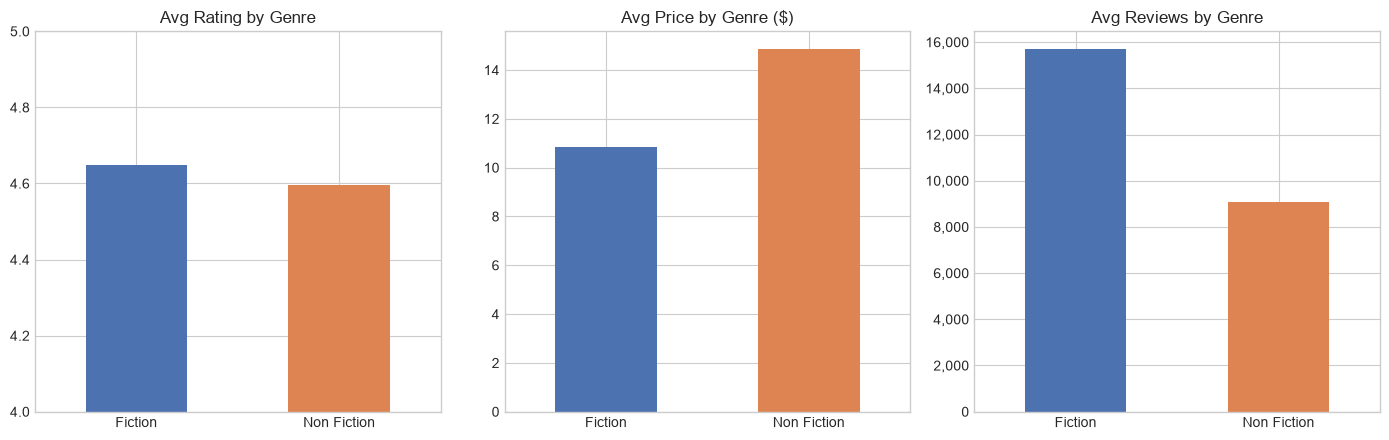

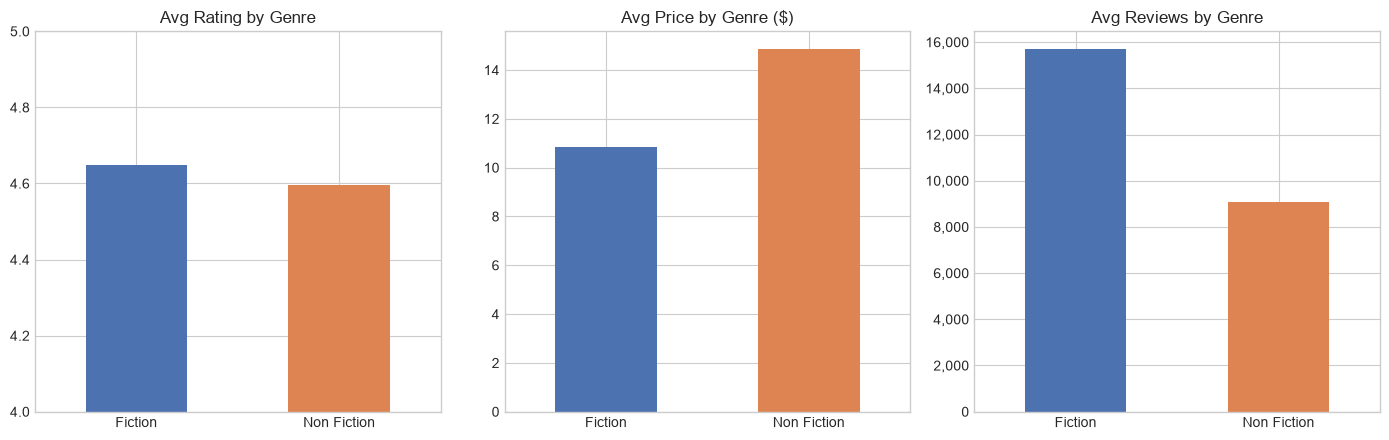

In [7]:
fig, genre_stats = eda.genre_comparison(df)
display(genre_stats)
fig

**Insight:** Fiction rates marginally higher (4.65 vs 4.60) and is priced
lower on average (~$10.85 vs ~$14.84), but draws far more reviews on average
(~15,684 vs ~9,065). This suggests Fiction readers engage/review more actively
per book, even though Non Fiction titles are slightly more numerous in this
list (310 vs 240 book-year entries) and commonly priced higher — plausibly
reflecting non-fiction's positioning as premium/reference material.

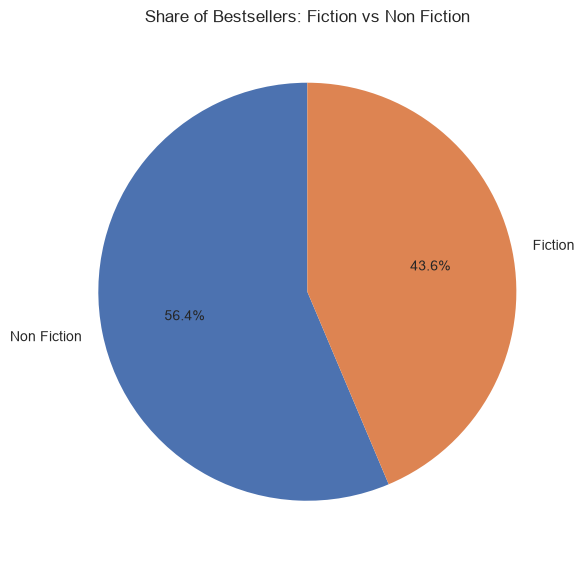

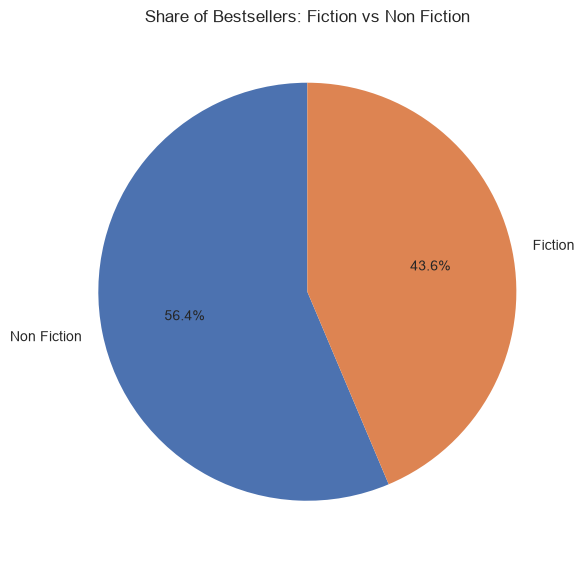

In [8]:
fig = eda.genre_share_pie(df)
fig

## 4. Year Analysis (2009–2019)

**Business question:** How have reader engagement and pricing shifted over
the decade?

Note: the number of books per year is constant at 50 (Amazon's Top 50 list by
design), so we don't chart that as a trend — it carries no analytical signal.

,avg_rating,avg_reviews,avg_price,book_count
year,,,,
2009,4.584,4710.12,15.40,50
2010,4.558,5479.62,13.48,50
2011,4.558,8100.82,15.10,50
2012,4.532,13090.92,15.30,50
2013,4.554,13098.14,14.60,50
2014,4.622,15859.94,14.64,50
2015,4.648,14233.38,10.42,50
2016,4.678,14196.00,13.18,50
2017,4.660,12888.40,11.38,50


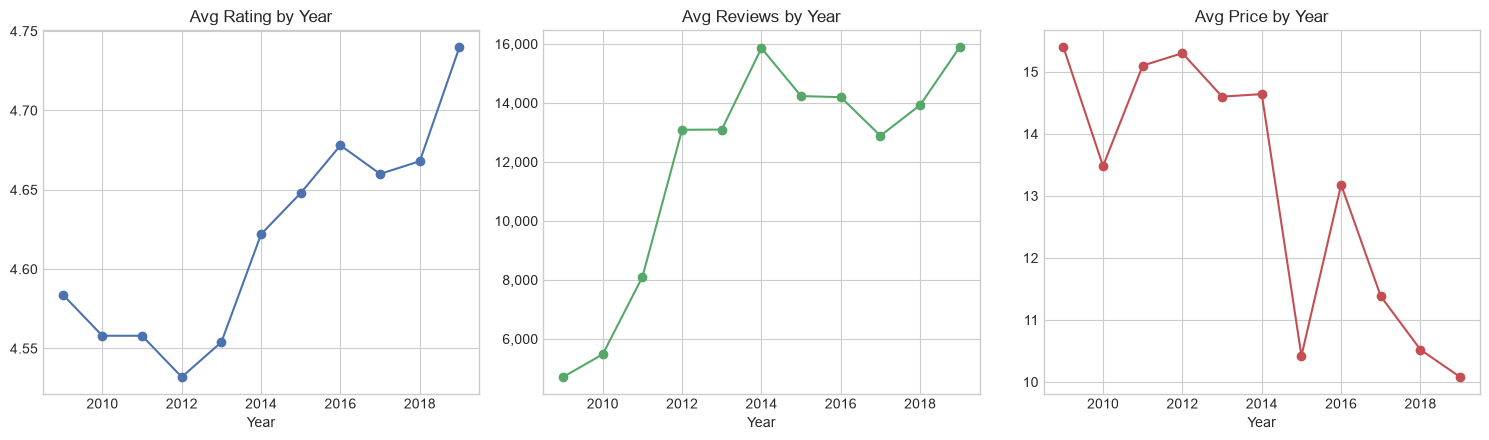

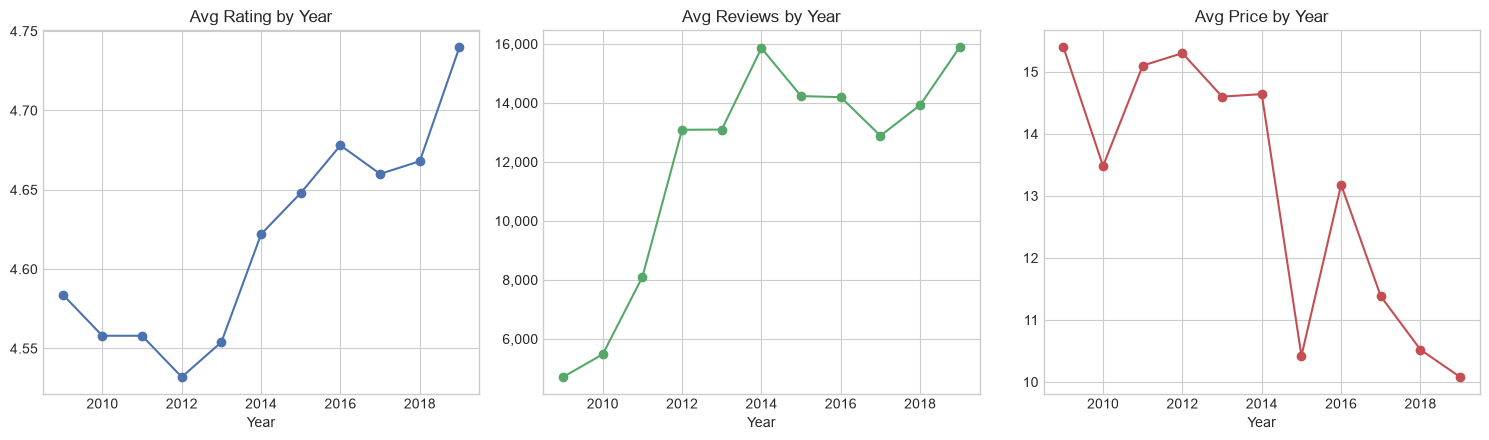

In [9]:
fig, year_stats = eda.yearly_trends(df)
display(year_stats)
fig

**Insight:** Average reviews per book more than tripled from 2009 (~4,710)
to 2019 (~15,898) — reflecting Amazon's overall platform growth and increasing
review culture over the decade, not necessarily book quality improving. Average
price meanwhile trended down (~$15.40 to ~$10.08), consistent with the broader
e-book/Kindle price deflation trend across this period. Average rating also
rose modestly (4.58 to 4.74), though this is a softer signal given rating
compression near the top of the scale.

## 5. Correlation Analysis

**Business question:** Does price predict quality? Does review volume predict
rating (social proof)?

,user_rating,reviews,price
user_rating,1.000000,-0.001729,-0.133086
reviews,-0.001729,1.000000,-0.109182
price,-0.133086,-0.109182,1.000000


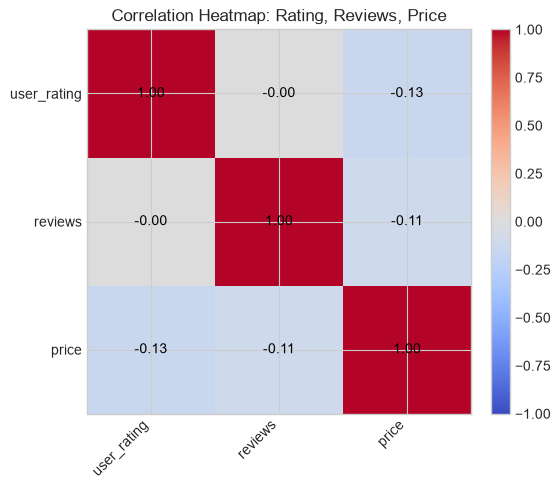

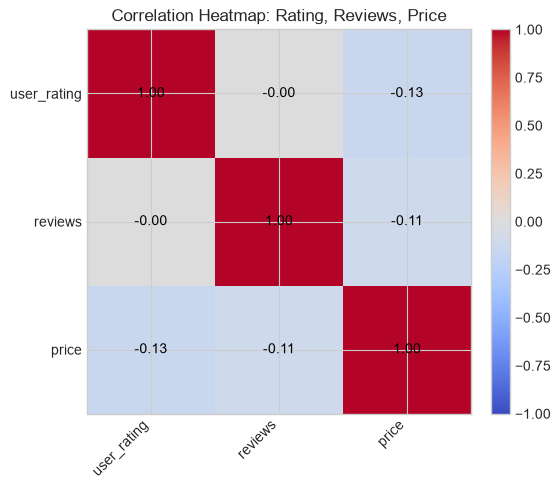

In [10]:
fig, corr = eda.correlation_heatmap(df)
display(corr)
fig

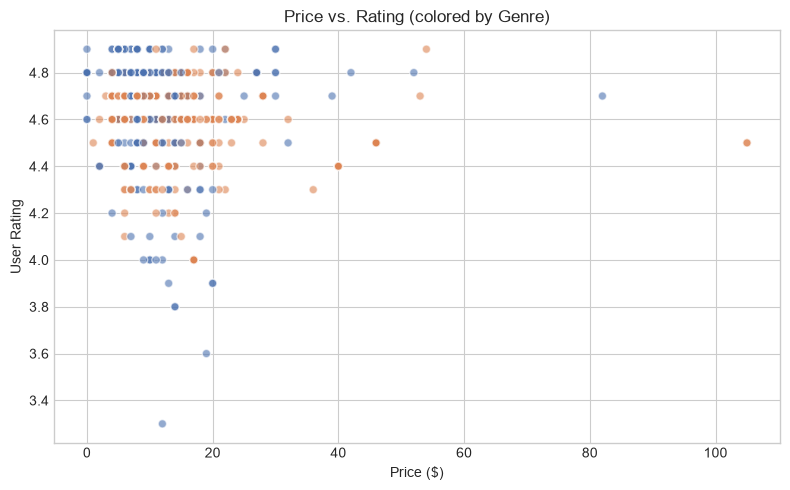

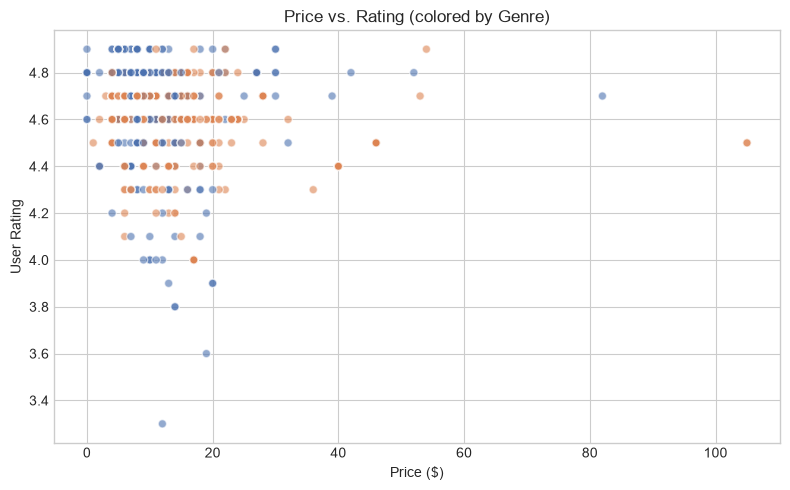

In [11]:
fig = eda.price_vs_rating_scatter(df)
fig

**Insight:** All three correlations are weak (each under 0.15 in magnitude).
Price does **not** meaningfully predict rating (-0.13) — expensive books aren't
reliably better-rated ones. Review count also doesn't meaningfully predict
rating (-0.002) — a heavily-reviewed book isn't reliably a better-rated book
either. **Important nuance:** correlation this weak doesn't mean 'no
relationship' definitively — it means no strong *linear* relationship exists
in this sample. This is a key distinction to be able to explain confidently:
correlation ≠ causation, and weak correlation ≠ proof of independence.

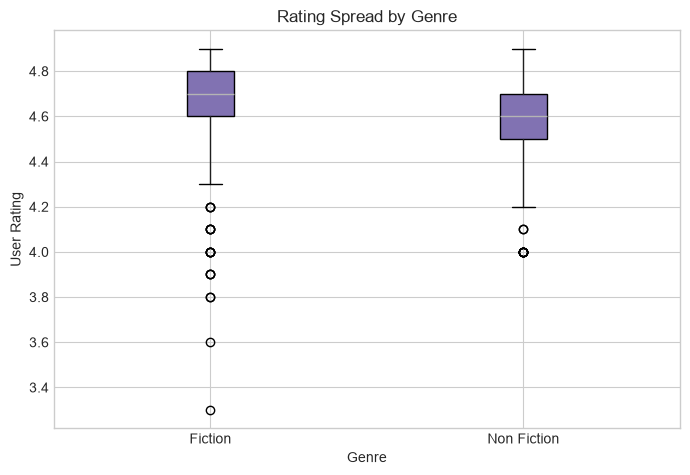

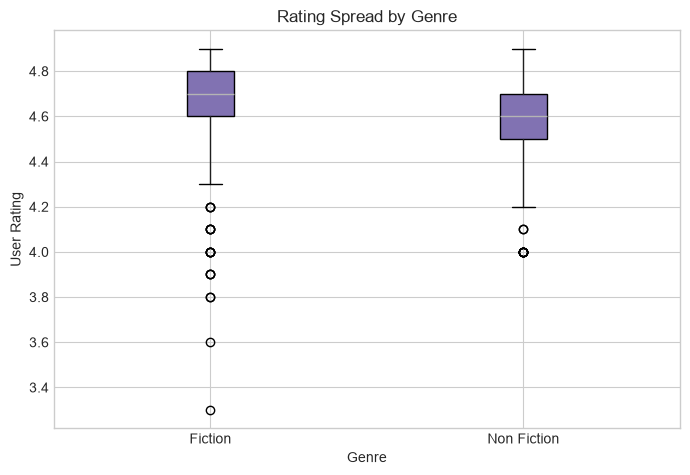

In [12]:
fig = eda.rating_boxplot_by_genre(df)
fig

## Summary of Key Findings

1. Series/franchise authors (Kinney, Collins, Riordan) dominate by book count — bestseller frequency often reflects franchise momentum, not necessarily standalone quality.
2. Fiction rates slightly higher and draws far more reviews than Non Fiction, despite being priced lower on average.
3. Reviews per book roughly tripled from 2009 to 2019, reflecting platform growth over the decade.
4. Average price declined over the same period, consistent with e-book price deflation.
5. Price and review count show negligible correlation with rating — buyers do not reliably pay more for, or leave more reviews on, higher-rated books in this dataset.
6. A small number of $0-priced books are genuine promotional/public-domain listings, not data errors — verified during cleaning rather than assumed.